## Module 4: Algorithmic Bias Project
### By Jennifer Panula

#### ChatGPT assistance was used for some coding help and help to generate ideas on how to utilize the data for this analysis. 


In [1]:
#pip install geopandas

In [83]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
# Read the full provided file
df_mort = pd.read_csv('data/mortgage_covenant_data.csv')

In [85]:
df_mort.info(verbose = True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100931 entries, 0 to 100930
Data columns (total 14 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   activity_year                      100931 non-null  int64  
 1   census_tract                       99915 non-null   float64
 2   derived_race                       100931 non-null  object 
 3   action_taken                       100931 non-null  int64  
 4   loan_amount                        100931 non-null  float64
 5   property_value                     83491 non-null   float64
 6   income                             88200 non-null   float64
 7   interest_rate                      78125 non-null   float64
 8   tract_minority_population_percent  100931 non-null  float64
 9   tract_to_msa_income_percentage     100931 non-null  float64
 10  denial_reason-1                    100931 non-null  int64  
 11  covenant_count                     1009

In [86]:
df_mort.sample(5)

,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
59938,2023,2.717110e+10,White,1,85000.0,85000.0,78.0,7.850,9.20,97.03,10,0.0,True,NaN
6563,2023,2.705107e+10,White,1,75000.0,75000.0,38.0,6.959,6.19,98.96,10,0.0,True,NaN
54738,2023,2.717110e+10,White,1,335000.0,435000.0,92.0,5.990,13.89,116.79,10,0.0,True,NaN
97180,2023,2.705310e+10,White,1,15000.0,215000.0,57.0,NaN,78.20,58.66,10,4.0,True,Low (1-50)
96508,2023,2.705302e+10,White,3,455000.0,505000.0,113.0,NaN,18.91,149.30,1,317.0,False,Very High (>200)


### What is a Census Tract? 
**Geographic regions, typically several in each county, used for statistical division. Averages around 4000 inhabitants.
-Wikipedia https://en.wikipedia.org/wiki/Census_tract 

## Description of fields
- census_tract: 11 digit census tract number
- derived_race: Single aggregated race categorization derived from applicant/borrower and co-applicant/co-borrower race fields
- action_taken: The action taken on the covered loan or application
1 - Loan originated
2 - Application approved but not accepted
3 - Application denied
4 - Application withdrawn by applicant
5 - File closed for incompleteness
6 - Purchased loan
7 - Preapproval request denied
8 - Preapproval request approved but not accepted
  
- tract_minority_population_percent: Percentage of minority population to total population for tract, rounded to two decimal places
- tract_to_msa_income_percentage: Percentage of tract median family income compared to MSA/MD median family income (the midpoint of family income within a specific Metropolitan Statistical Area (MSA) or Metropolitan Division (MD), used to classify the income level of a census tract) https://apps.ffiec.gov/census/htm/2020CensusInfoSheet.htm 
- denial_reason-1: The principal reason, or reasons, for denial
1 - Debt-to-income ratio
2 - Employment history
3 - Credit history
4 - Collateral
5 - Insufficient cash (downpayment, closing costs)
6 - Unverifiable information
7 - Credit application incomplete
8 - Mortgage insurance denied
9 - Other
10 - Not applicable
- covenant_count:
- was_approved: Whether or not the loan application was approved
- covenant_density: derived field from provided file, categorizing density of covenants by low, medium, high or very high.

Descriptions largely located from https://ffiec.cfpb.gov/documentation/publications/loan-level-datasets/lar-data-fields except the derived fields from the provided file for this project. 


## Initial exploration of Data

In [87]:
#exploring covenant density
df_mort['covenant_density'].describe()

count          11169
unique             4
top       Low (1-50)
freq            4537
Name: covenant_density, dtype: object

In [88]:
df_mort['covenant_density'].value_counts()

covenant_density
Low (1-50)          4537
Very High (>200)    3140
Medium (51-100)     1772
High (101-200)      1720
Name: count, dtype: int64

Text(0.5, 1.0, 'Covenant Density Category Counts')

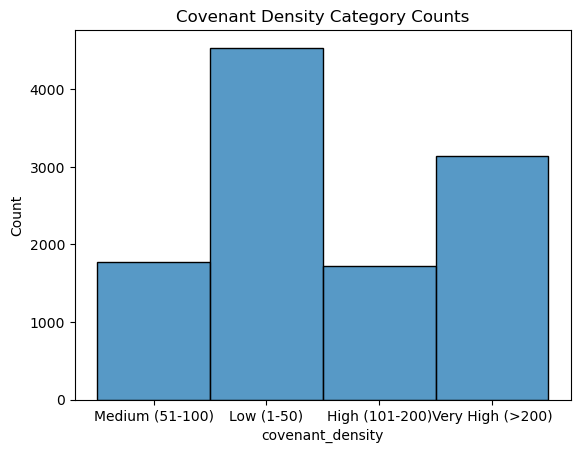

In [89]:
sns.histplot(df_mort['covenant_density'])
plt.title("Covenant Density Category Counts")

In [90]:
#exploring covenant count
df_mort['covenant_count'].describe()

count    100931.000000
mean         17.408101
std          84.973673
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         965.000000
Name: covenant_count, dtype: float64

In [91]:
df_mort['covenant_count'].value_counts()

covenant_count
0.0      89762
1.0        684
3.0        532
2.0        488
212.0      294
         ...  
176.0       29
15.0        28
126.0       27
57.0        27
485.0       25
Name: count, Length: 112, dtype: int64

In [92]:
#112 distinct covenant counts, curious to see if this is a count of covenants by tract. Lets look at how many tracts there are...
df_mort['census_tract'].value_counts()

census_tract
2.705303e+10    606
2.716307e+10    580
2.705303e+10    432
2.705303e+10    420
2.717110e+10    384
               ... 
2.712304e+10      4
2.712303e+10      3
2.713700e+10      2
2.710900e+10      1
2.714501e+10      1
Name: count, Length: 1494, dtype: int64

In [93]:
df_no_cov = df_mort.groupby('census_tract').filter(lambda g: (g['covenant_count'] == 0).any())
df_no_cov

,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
0,2023,2.703706e+10,Race Not Available,6,185000.0,195000.0,NaN,6.125,40.37,73.48,10,0.0,False,NaN
1,2023,2.714103e+10,Race Not Available,6,375000.0,385000.0,NaN,6.625,10.64,121.26,10,0.0,False,NaN
2,2023,2.702395e+10,Race Not Available,6,105000.0,105000.0,NaN,6.125,8.92,90.13,10,0.0,False,NaN
3,2023,2.717110e+10,Race Not Available,6,285000.0,285000.0,NaN,6.750,13.27,104.37,10,0.0,False,NaN
4,2023,2.715948e+10,Race Not Available,6,175000.0,175000.0,NaN,6.875,5.87,82.22,10,0.0,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100926,2023,2.700902e+10,Race Not Available,6,255000.0,265000.0,NaN,6.125,4.88,106.18,10,0.0,False,NaN
100927,2023,2.706778e+10,Race Not Available,6,185000.0,335000.0,NaN,6.125,46.58,74.68,10,0.0,False,NaN
100928,2023,2.714948e+10,Race Not Available,6,65000.0,75000.0,NaN,6.750,20.14,118.83,10,0.0,False,NaN
100929,2023,2.705913e+10,Race Not Available,6,545000.0,525000.0,NaN,5.000,6.84,90.07,10,0.0,False,NaN


In [94]:
df_no_cov['census_tract'].value_counts()

census_tract
2.705303e+10    606
2.716307e+10    580
2.705303e+10    432
2.705303e+10    420
2.717110e+10    384
               ... 
2.712304e+10      4
2.712303e+10      3
2.713700e+10      2
2.710900e+10      1
2.714501e+10      1
Name: count, Length: 1333, dtype: int64

Out of the 1494 Census tracts in the file, 1333 had zero convenants. Thus, 161 or 10.78% of the tracts had covenants

In [95]:
#fill NaNs on the covenant_density field with None to create another category for comparison
df_mort['covenant_density'] = df_mort['covenant_density'].fillna('None')

In [96]:
df_clean = df_mort.dropna()
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 66858 entries, 62 to 100923
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   activity_year                      66858 non-null  int64  
 1   census_tract                       66858 non-null  float64
 2   derived_race                       66858 non-null  object 
 3   action_taken                       66858 non-null  int64  
 4   loan_amount                        66858 non-null  float64
 5   property_value                     66858 non-null  float64
 6   income                             66858 non-null  float64
 7   interest_rate                      66858 non-null  float64
 8   tract_minority_population_percent  66858 non-null  float64
 9   tract_to_msa_income_percentage     66858 non-null  float64
 10  denial_reason-1                    66858 non-null  int64  
 11  covenant_count                     66858 non-null  float6

In [97]:
df_cove = df_mort[df_mort['covenant_density'] != "None"]
df_cove.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11169 entries, 36 to 100922
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   activity_year                      11169 non-null  int64  
 1   census_tract                       11169 non-null  float64
 2   derived_race                       11169 non-null  object 
 3   action_taken                       11169 non-null  int64  
 4   loan_amount                        11169 non-null  float64
 5   property_value                     9381 non-null   float64
 6   income                             9641 non-null   float64
 7   interest_rate                      8980 non-null   float64
 8   tract_minority_population_percent  11169 non-null  float64
 9   tract_to_msa_income_percentage     11169 non-null  float64
 10  denial_reason-1                    11169 non-null  int64  
 11  covenant_count                     11169 non-null  float6

I have created a few copies of the dataset for now, because at the moment I am uncertain which will be most relevant to analyze. 
- df_mort = the original data, but the many NaNs in the covenant density field is filled with "None" string. It may be reasonable to compare the entries that historically had a covenant vs entries that didn't, which I hypothesise may be larely areas of the Twin Cities metro that developed after the outlawing of covenants. 
- df_clean = df_mort with all NAs dropped, resulting in 66,858 entries (trimmed from original 100,931 entries)
- df_cove = df_mort but dropping the covenant density fields that are "None" (or started out as NaN). This dataset trims things significantly to 11,169 entries and still have many relevant paramaters with additional null values (such as property value).

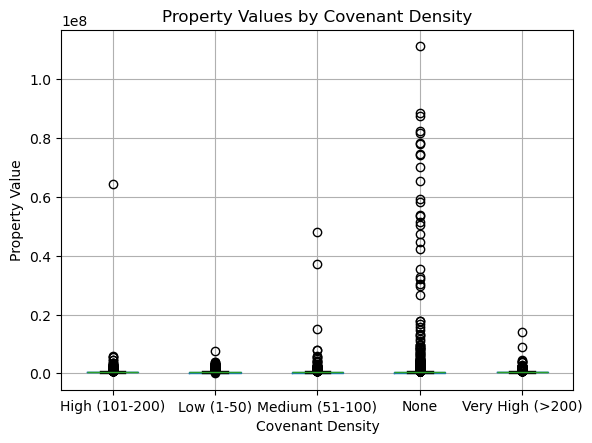

In [98]:
df_mort.boxplot(column='property_value', by='covenant_density')
plt.title('Property Values by Covenant Density')
plt.suptitle('')
plt.xlabel('Covenant Density')
plt.ylabel('Property Value')
plt.show()

In [99]:
#looking at property values to get an idea of how extreme the outliers are
df_mort['property_value'].describe()

count    8.349100e+04
mean     3.987726e+05
std      1.197102e+06
min      5.000000e+03
25%      2.350000e+05
50%      3.250000e+05
75%      4.350000e+05
max      1.113250e+08
Name: property_value, dtype: float64

In [100]:
# there's a lot of outliers (with property values), lets cut out the highest 1% 
cutoff = df_mort['property_value'].quantile(0.99)
df_no_outliers = df_mort[df_mort['property_value'] <= cutoff]
df_no_outliers

,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
0,2023,2.703706e+10,Race Not Available,6,185000.0,195000.0,NaN,6.125,40.37,73.48,10,0.0,False,None
1,2023,2.714103e+10,Race Not Available,6,375000.0,385000.0,NaN,6.625,10.64,121.26,10,0.0,False,None
2,2023,2.702395e+10,Race Not Available,6,105000.0,105000.0,NaN,6.125,8.92,90.13,10,0.0,False,None
3,2023,2.717110e+10,Race Not Available,6,285000.0,285000.0,NaN,6.750,13.27,104.37,10,0.0,False,None
4,2023,2.715948e+10,Race Not Available,6,175000.0,175000.0,NaN,6.875,5.87,82.22,10,0.0,False,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100926,2023,2.700902e+10,Race Not Available,6,255000.0,265000.0,NaN,6.125,4.88,106.18,10,0.0,False,None
100927,2023,2.706778e+10,Race Not Available,6,185000.0,335000.0,NaN,6.125,46.58,74.68,10,0.0,False,None
100928,2023,2.714948e+10,Race Not Available,6,65000.0,75000.0,NaN,6.750,20.14,118.83,10,0.0,False,None
100929,2023,2.705913e+10,Race Not Available,6,545000.0,525000.0,NaN,5.000,6.84,90.07,10,0.0,False,None


<Axes: xlabel='property_value', ylabel='Count'>

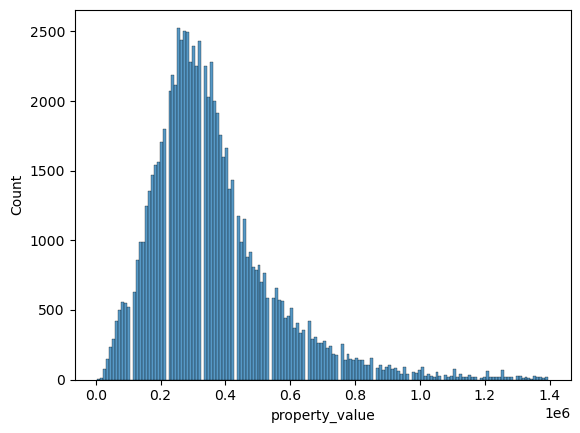

In [101]:
sns.histplot(df_no_outliers['property_value'])

In [102]:
#now the homes with higest values are $1.395M. 
df_no_outliers['property_value'].sort_values(ascending=False).head(10)

91126    1395000.0
88215    1395000.0
74843    1395000.0
20273    1395000.0
20272    1395000.0
35199    1395000.0
1940     1395000.0
79947    1395000.0
69936    1395000.0
70273    1395000.0
Name: property_value, dtype: float64

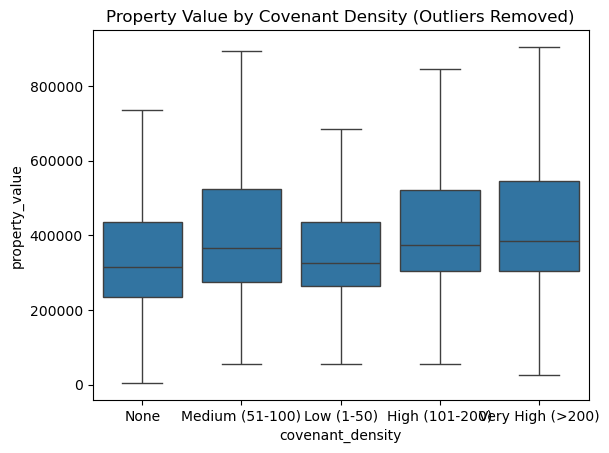

In [103]:
#outliers removed - the plots were still hard to visualize with the remaining outliers, even after the cutoff in prior code blocks.
sns.boxplot(x='covenant_density', y='property_value', data=df_mort, showfliers=False)
# sns.boxplot(x='covenant_density', y='property_value', data=df_no_outliers)
plt.title("Property Value by Covenant Density (Outliers Removed)")
plt.show()

In [104]:
#creating summary table as alternate to view relationship between these two paramaters
cov_value_summary = df_mort.groupby('covenant_density')['property_value'].agg(
    count='count',
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max'
)

cov_value_summary

,count,mean,median,std,min,max
covenant_density,,,,,,
High (101-200),1438,547739.916551,375000.0,1.749168e+06,55000.0,64405000.0
Low (1-50),3779,418831.701508,325000.0,3.404951e+05,5000.0,7625000.0
Medium (51-100),1504,567187.500000,365000.0,1.682592e+06,55000.0,48055000.0
None,74110,387560.383214,315000.0,1.217206e+06,5000.0,111325000.0
Very High (>200),2660,506902.255639,385000.0,4.906733e+05,25000.0,14205000.0


In [105]:
median_values = df_mort.groupby('covenant_density')['property_value'].median()
median_values

covenant_density
High (101-200)      375000.0
Low (1-50)          325000.0
Medium (51-100)     365000.0
None                315000.0
Very High (>200)    385000.0
Name: property_value, dtype: float64

In [106]:
order = ['None','Low (1-50)','Medium (51-100)','High (101-200)','Very High (>200)']

df_mort['covenant_density'] = pd.Categorical(
    df_mort['covenant_density'],
    categories=order,
    ordered=True
)

([0, 1, 2, 3, 4],
 [Text(0, 0, 'None'),
  Text(1, 0, 'Low (1-50)'),
  Text(2, 0, 'Medium (51-100)'),
  Text(3, 0, 'High (101-200)'),
  Text(4, 0, 'Very High (>200)')])

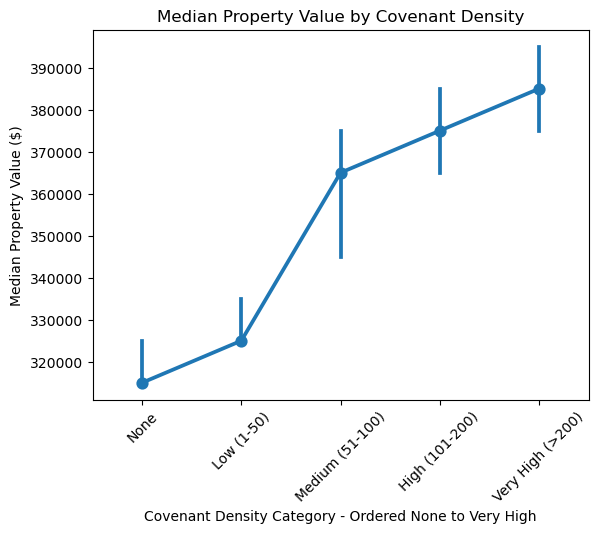

In [107]:
sns.pointplot(
    x='covenant_density',
    y='property_value',
    data=df_mort,
    estimator=np.median,
    order=order)
plt.title("Median Property Value by Covenant Density")
plt.xlabel("Covenant Density Category - Ordered None to Very High")
plt.ylabel("Median Property Value ($)")

plt.xticks(rotation=45)   # rotate x-axis labels


## Summary - Relationship between Covenant Density and Property Value

Going off the median (which is reasonable as the median is less influences by outliers), we see a correlation between density and property value, with the highest density categories having the highest median values and the lowest-to-none covenant densities correlating with the lower median values. 

# Now lets examine Approval trends


In [108]:
#average approval rate
df_mort['was_approved'].mean()

np.float64(0.6646619968097017)

In [109]:
#what does our dataset look like in regards to derived race?
df_mort['derived_race'].value_counts()

derived_race
White                                        63627
Race Not Available                           22811
Asian                                         5905
Black or African American                     5199
Joint                                         2427
American Indian or Alaska Native               709
2 or more minority races                       135
Native Hawaiian or Other Pacific Islander      113
Free Form Text Only                              5
Name: count, dtype: int64

Important to point out "Race not available" is the second-highest category. The non-white categories are quite unbalanced, so let's keep that in mind as we continue to explore the data. But meanwhile, let's get rid of "Free Form Text Only" field. 

In [110]:
df_mort = df_mort[df_mort['derived_race'] != "Free Form Text Only"]

In [111]:
#how about approval rates by race...
df_mort.groupby('derived_race')['was_approved'].mean().sort_values()

derived_race
Race Not Available                           0.405725
Native Hawaiian or Other Pacific Islander    0.566372
Black or African American                    0.604155
American Indian or Alaska Native             0.622003
2 or more minority races                     0.659259
Asian                                        0.707705
Joint                                        0.744129
White                                        0.756063
Name: was_approved, dtype: float64

In [112]:
df_mort['tract_minority_population_percent'].value_counts()

tract_minority_population_percent
0.00     1016
20.69     649
27.78     580
10.98     573
14.61     441
         ... 
83.09       6
27.64       5
43.94       4
95.63       3
23.88       1
Name: count, Length: 1245, dtype: int64

In [113]:
df_mort['tract_minority_population_percent'].describe()

count    100926.000000
mean         22.873976
std          17.293309
min           0.000000
25%          10.140000
50%          18.640000
75%          29.710000
max          95.630000
Name: tract_minority_population_percent, dtype: float64

In [114]:
df_mort['minority_bin'] = pd.qcut(
    df_mort['tract_minority_population_percent'],
    4,
    labels=['Low','Medium-Low','Medium-High','High']
)

df_mort.groupby('minority_bin')['was_approved'].mean()

C:\Users\jenpa\AppData\Local\Temp\ipykernel_35692\2055272263.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mort.groupby('minority_bin')['was_approved'].mean()


minority_bin
Low            0.671210
Medium-Low     0.680377
Medium-High    0.667558
High           0.639207
Name: was_approved, dtype: float64

In [115]:
df_mort['income'].describe()

count    8.819500e+04
mean     1.489675e+02
std      5.568984e+03
min     -3.415700e+04
25%      6.700000e+01
50%      9.600000e+01
75%      1.460000e+02
max      1.651000e+06
Name: income, dtype: float64

In [116]:
#what's with the negative income? should we get rid of the negative income items?
df_mort['income'].sort_values(ascending=True).head(30)

72870   -34157.0
69936    -1661.0
58465     -994.0
43729     -196.0
92862     -108.0
22588      -93.0
7953       -93.0
64939      -54.0
47694      -51.0
59213      -45.0
11092      -45.0
11093      -45.0
11060      -38.0
92852      -35.0
92851      -29.0
92854      -14.0
70590      -10.0
7834        -8.0
69265       -8.0
33536       -7.0
92962       -5.0
75141       -3.0
76300        0.0
9091         0.0
8060         0.0
57549        0.0
91082        0.0
86428        0.0
16410        0.0
31650        0.0
Name: income, dtype: float64

In [117]:
df_mort = df_mort[df_mort['income'] >= 0]
df_mort['income'].sort_values(ascending=True).head()

55641    0.0
12632    0.0
42635    0.0
71833    0.0
55702    0.0
Name: income, dtype: float64

In [118]:
df_mort['income_bin'] = pd.qcut(df_mort['income'], 4)

df_mort.groupby('income_bin')['was_approved'].mean()


C:\Users\jenpa\AppData\Local\Temp\ipykernel_35692\969461289.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mort.groupby('income_bin')['was_approved'].mean()


income_bin
(-0.001, 67.0]        0.639131
(67.0, 96.0]          0.728950
(96.0, 146.0]         0.762342
(146.0, 1651000.0]    0.784217
Name: was_approved, dtype: float64

Text(0.5, 1.0, 'Property Values by Loan Approval Decision (Outliers Removed)')

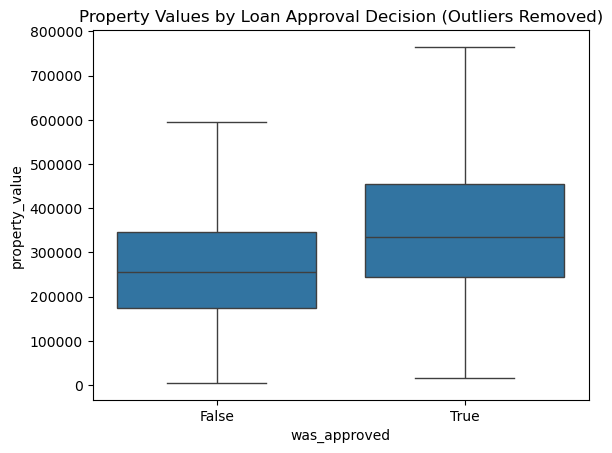

In [119]:
#approval vs proerty value
sns.boxplot(
    x='was_approved',
    y='property_value',
    data=df_mort, showfliers = False
)

plt.title("Property Values by Loan Approval Decision (Outliers Removed)")

In [120]:
df_mort.groupby('covenant_density')['was_approved'].mean()

C:\Users\jenpa\AppData\Local\Temp\ipykernel_35692\222843858.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mort.groupby('covenant_density')['was_approved'].mean()


covenant_density
None                0.727243
Low (1-50)          0.717832
Medium (51-100)     0.743119
High (101-200)      0.759459
Very High (>200)    0.749255
Name: was_approved, dtype: float64

Text(0.5, 1.0, 'Mortgage Approval Rates by Covenant Density')

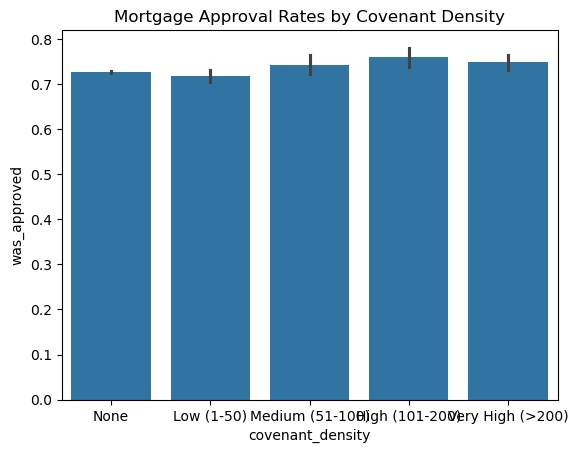

In [121]:
sns.barplot(
    x='covenant_density',
    y='was_approved',
    data=df_mort,
    estimator=np.mean, order= order
)

plt.title("Mortgage Approval Rates by Covenant Density")

In [122]:
df_mort['denial_reason-1'].value_counts()

denial_reason-1
10      80040
1111     2455
1        2182
3        1182
4         754
9         464
7         381
5         277
6         260
2         178
Name: count, dtype: int64

In [123]:
df_mort[df_mort['was_approved'] == 0]['denial_reason-1'].value_counts()

denial_reason-1
10      17908
1        2182
3        1182
4         754
9         464
7         381
1111      370
5         277
6         260
2         178
Name: count, dtype: int64

In [124]:
pd.crosstab(
    df_mort[df_mort['was_approved'] == 0]['derived_race'],
    df_mort[df_mort['was_approved'] == 0]['denial_reason-1']
)

denial_reason-1,1,2,3,4,5,6,7,9,10,1111
derived_race,,,,,,,,,,
2 or more minority races,7,1,3,2,0,0,0,0,33,0
American Indian or Alaska Native,22,0,37,11,4,4,6,4,172,4
Asian,167,9,38,66,16,25,16,28,1335,7
Black or African American,245,21,105,55,44,36,32,37,1462,7
Joint,46,4,33,13,3,4,10,11,481,8
Native Hawaiian or Other Pacific Islander,8,1,6,1,1,1,0,4,27,0
Race Not Available,450,27,218,97,48,56,63,97,2779,93
White,1237,115,742,509,161,134,254,283,11619,251


I wondered about the many values for the code 10 which is N/A for denial reason. was_approved is a derived field,

combined_data['was_approved'] = combined_data['action_taken'].isin([1, 2])

with reason 2 being "approved but not accepted" and the other fields not all aligning with flat-out denial, I hypothesize that this may be part of the reason for so many N/A (denial reason 10) values here. 

## Patterns and Potential proxys for historical discrimination 

In [125]:
key_corr = df_mort[['covenant_count',
         'tract_minority_population_percent',
         'tract_to_msa_income_percentage',
         'property_value',
         'income']].corr()
key_corr

,covenant_count,tract_minority_population_percent,tract_to_msa_income_percentage,property_value,income
covenant_count,1.000000,0.020871,0.132767,0.101917,0.001298
tract_minority_population_percent,0.020871,1.000000,-0.363290,-0.120136,-0.000720
tract_to_msa_income_percentage,0.132767,-0.363290,1.000000,0.407396,0.005721
property_value,0.101917,-0.120136,0.407396,1.000000,0.554502
income,0.001298,-0.000720,0.005721,0.554502,1.000000


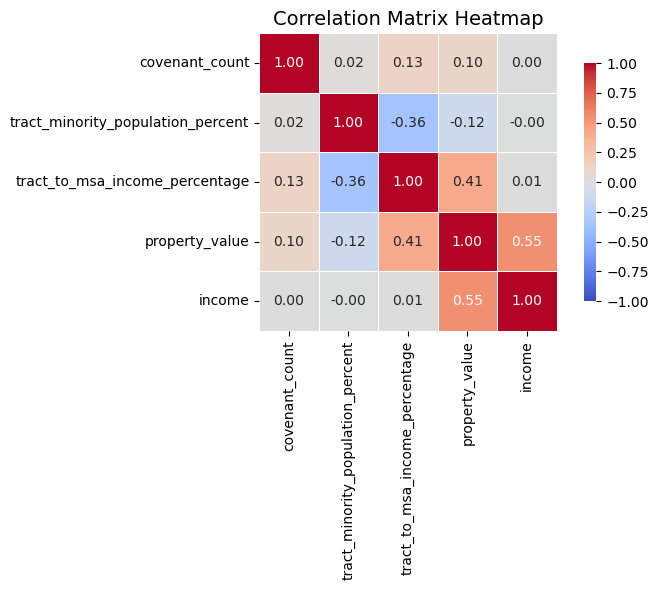

In [126]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    key_corr,
    annot=True,        # Show correlation values
    fmt=".2f",         # Format to 2 decimal places
    cmap='coolwarm',   # Color map
    vmin=-1, vmax=1,   # Fix scale from -1 to 1
    square=True,       # Make cells square
    linewidths=0.5,    # Add lines between cells
    cbar_kws={"shrink": 0.8}  # Colorbar size
)

plt.title("Correlation Matrix Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

In [127]:
df_mort.groupby('covenant_density')['tract_minority_population_percent'].mean()

C:\Users\jenpa\AppData\Local\Temp\ipykernel_35692\1896031341.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mort.groupby('covenant_density')['tract_minority_population_percent'].mean()


covenant_density
None                21.910619
Low (1-50)          37.569407
Medium (51-100)     27.014187
High (101-200)      24.116466
Very High (>200)    25.434132
Name: tract_minority_population_percent, dtype: float64

<Axes: xlabel='covenant_density', ylabel='tract_minority_population_percent'>

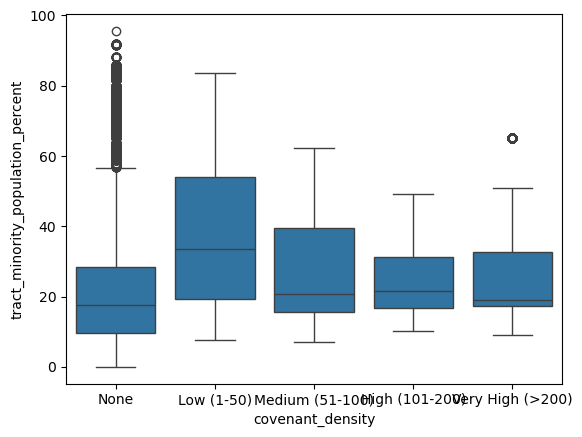

In [128]:
sns.boxplot(
    x='covenant_density',
    y='tract_minority_population_percent',
    data=df_mort
)

High covenant areas have lower minority populations, which suggests persistent segregation effects.

In [129]:
df_mort.groupby('covenant_density')['tract_to_msa_income_percentage'].mean()

C:\Users\jenpa\AppData\Local\Temp\ipykernel_35692\3659966123.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mort.groupby('covenant_density')['tract_to_msa_income_percentage'].mean()


covenant_density
None                100.559079
Low (1-50)           99.329742
Medium (51-100)     112.743093
High (101-200)      116.858432
Very High (>200)    123.159896
Name: tract_to_msa_income_percentage, dtype: float64

If covenant areas have higher neighborhood income relative to the metro, that suggests persistent economic advantages. However, in this case, only the low category is underpar by a small margin.

In [130]:
df_mort.groupby('covenant_density')[[
    'tract_minority_population_percent',
    'tract_to_msa_income_percentage',
    'property_value'
]].mean()

C:\Users\jenpa\AppData\Local\Temp\ipykernel_35692\3387232275.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mort.groupby('covenant_density')[[


,tract_minority_population_percent,tract_to_msa_income_percentage,property_value
covenant_density,,,
None,21.910619,100.559079,359282.330356
Low (1-50),37.569407,99.329742,419667.068394
Medium (51-100),27.014187,112.743093,516537.279016
High (101-200),24.116466,116.858432,507556.270096
Very High (>200),25.434132,123.159896,500542.380325


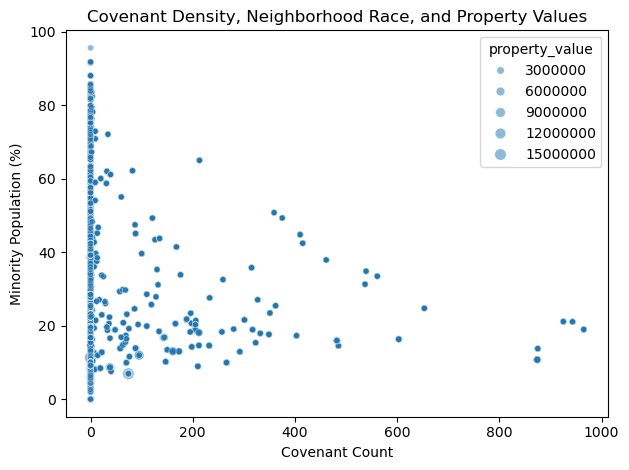

In [131]:
sns.scatterplot(
    x='covenant_count',
    y='tract_minority_population_percent',
    size='property_value',
    data=df_mort,
    alpha=0.5
)

plt.title("Covenant Density, Neighborhood Race, and Property Values")
plt.xlabel("Covenant Count")
plt.ylabel("Minority Population (%)")
plt.tight_layout()

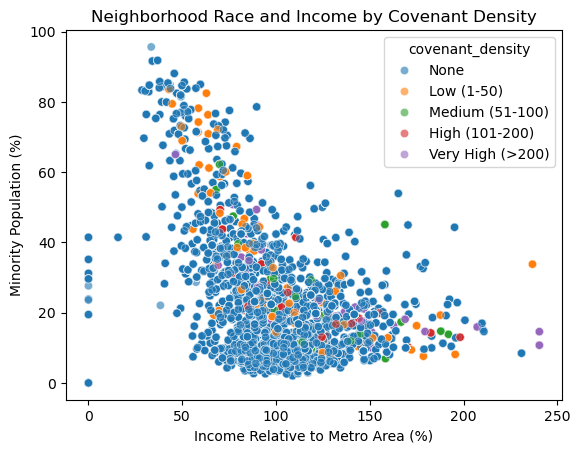

In [132]:
sns.scatterplot(
    x='tract_to_msa_income_percentage',
    y='tract_minority_population_percent',
    hue='covenant_density',
    data=df_mort,
    alpha=0.6
)

plt.title("Neighborhood Race and Income by Covenant Density")
plt.xlabel("Income Relative to Metro Area (%)")
plt.ylabel("Minority Population (%)")
plt.show()